# 長照 2.0 機構補助諮詢助手

##動機：

全台灣目前的長照機構高達 4033 家，且瀏覽後發現機構可以向政府申請的補助有很多種情形，所以製作一個機器人幫助照顧機構更快速的查詢自己能獲得的款項以提供更高品質的服務

##使用的資料集：
https://www.mohw.gov.tw/dl-92881-b226ce9a-7a75-4a5b-b810-714f2ff37c0a.html


## 程式碼實作

### requirements.txt

In [ ]:
# RAG 核心框架
langchain==1.2.10
langchain-community==0.4.1
langchain-core==1.2.19
langchain-google-genai==4.2.1
langchain-text-splitters==1.1.1

# 模型 API
google-generativeai==0.8.6

# 向量資料庫與嵌入 (Embedding)
faiss-cpu==1.13.2
sentence-transformers==5.2.3
tiktoken==0.12.0

# 資料處理與環境
numpy==2.0.2
python-dotenv==1.2.2
pydantic==2.12.3

# PDF 或文件解析 (如果你的補助資料是 PDF)
PyPDF2==3.0.1
lxml==6.0.2

### 下載套件

In [1]:
!pip install -U google-genai langchain-text-splitters langchain-community langchain-google-genai PyPDF2 faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 723.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.5/503.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Foun

### 掛載 Google Drive 並設定 Gemini API

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

pdf_path = '/content/drive/MyDrive/Credentials/Long-Term Care Funding Guidelines.pdf'

Mounted at /content/drive


In [2]:
from dotenv import load_dotenv

env_path = '/content/drive/MyDrive/Credentials/.env'

# 載入環境變數
if os.path.exists(env_path):
    load_dotenv(env_path)
    api_key = os.getenv('GEMINI_API_KEY')

    if api_key:
        print(f"成功取得 API Key: {api_key[:5]}******") # 隱藏部分字元以示安全
    else:
        print("找到 .env 檔案，但找不到 GEMINI_API_KEY 變數")
else:
    print(f"錯誤：找不到檔案 {env_path}")

成功取得 API Key: AIzaSyBhaM0bDqSwNN0lyJ******


### 讀取 PDF 並將文本切塊

In [14]:
import PyPDF2
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 讀取 PDF
def read_pdf(path):
    reader = PyPDF2.PdfReader(path)
    text = ""
    for page in reader.pages:
        text += page.extract_text() + "\n"
    return text

raw_text = read_pdf(pdf_path)

# 切塊
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)
chunks = splitter.split_text(raw_text)
print(f"共切出 {len(chunks)} 個 chunk")

共切出 122 個 chunk


### Embedding + 建立向量資料庫

In [15]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

# 用 Gemini Embedding 模型
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

# 建立 FAISS 向量庫
vectorstore = FAISS.from_texts(chunks, embeddings)
print("向量庫建立完成！")

向量庫建立完成！


### 諮詢助手

In [23]:
from google import genai

client = genai.Client(api_key=api_key)

def ask(question, k=4):
    docs = vectorstore.similarity_search(question, k=k)
    context = "\n\n".join([d.page_content for d in docs])

    prompt = f"""根據以下文件內容回答問題，若資訊不足請說不知道。

文件內容：
{context}

問題：{question}
"""
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )
    return response.text

answer = ask("""
5. 我家長輩失智併有 BPSD 症狀，在申請補助時有什麼要注意的？""")
print(answer)

根據文件內容，您的長輩若為失智症併有BPSD症狀，在申請相關補助時有以下幾點需要特別注意：

1.  **收案服務對象資格：**
    *   長輩必須被診斷為失智症，並且併有BPSD（行為與精神症狀）。
    *   需提供本部函頒的BPSD症狀界定範圍及相關證明文件。
    *   **每年**都需提交重新評估BPSD症狀界定範圍的診斷證明文件。

2.  **獎助金額與計算方式：**
    *   符合資格者，每人每月獎助新臺幣五千元。
    *   申請獎助月數，每人每年最高為十二個月。
    *   **收托天數影響金額：**
        *   失智症者併有BPSD個案收托天數未滿十二日為新臺幣二千五百元。
        *   失智症者併有BPSD個案收托天數十二日（含）以上為新臺幣五千元。

3.  **不能重複申請：**
    *   這項困難照顧獎勵津貼與「長期照顧服務申請及給付辦法」中的照顧困難服務加計 (AA05)費用，**應擇一申請，不可重複請領**。

這些獎助項目適用於日間照顧對象，以及小規模多機能的對象。


## Metric

分別詢問 Gemini 和此專案五個問題：
1. 「營養餐飲服務」每餐補助多少錢？一個人一天最多幾餐？
2. 我想申請「身心障礙者日間照顧機構費用」，最晚什麼時候要申請？
3. 我是中低收入戶，失智等級 CDR 2 分，住進團體家屋一個月補助多少？
4. 如果我在「桃園市復興區」當居服員，照顧 3 個以上的個案，每月有多少獎勵津貼？
5. 我家長輩失智併有 BPSD 症狀，在申請補助時有什麼要注意的？

結果分別如下:

### Gemini:

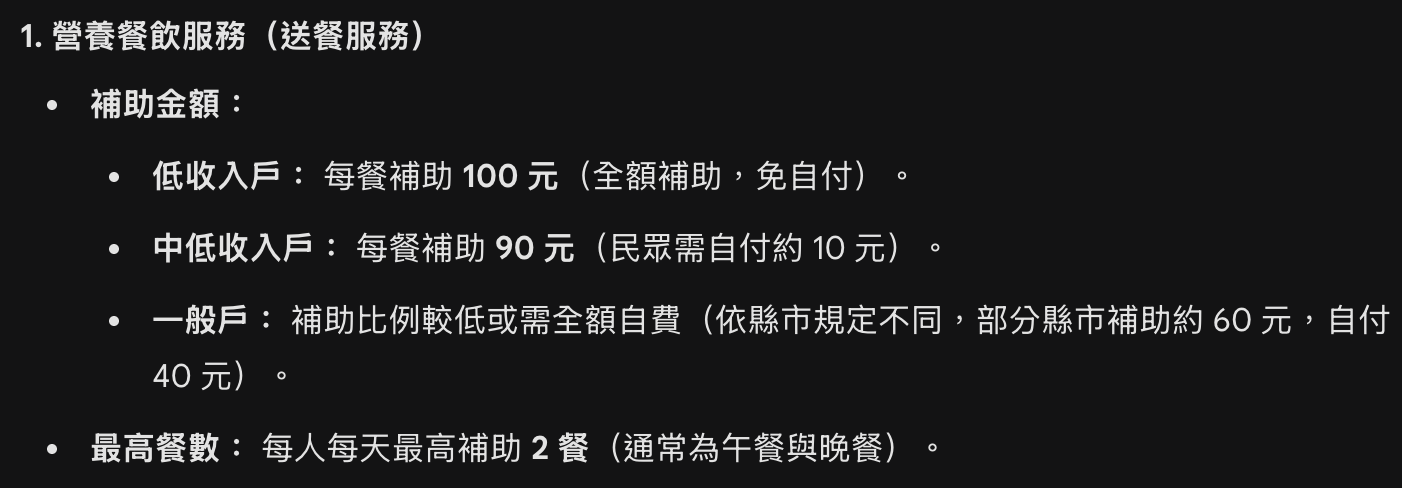

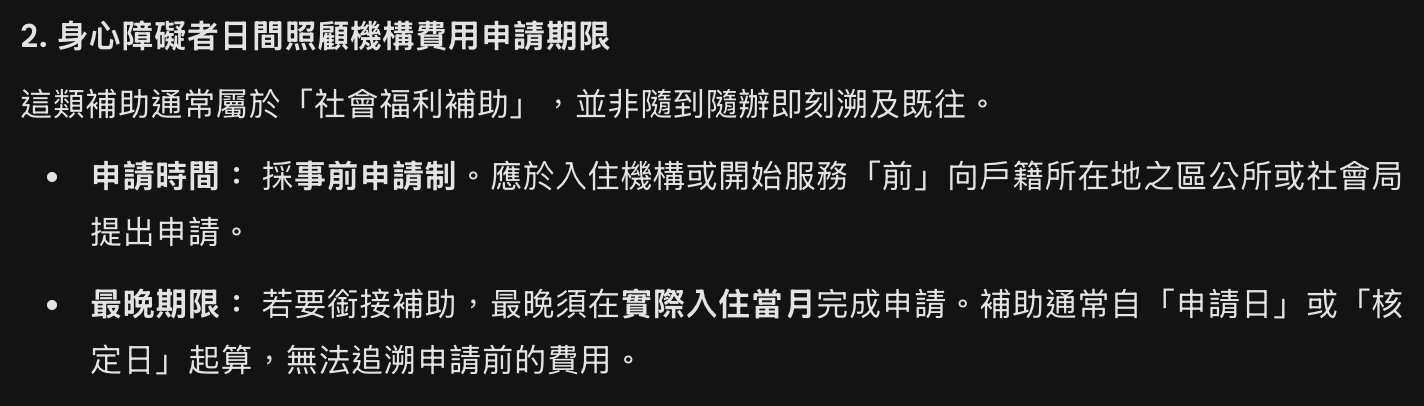

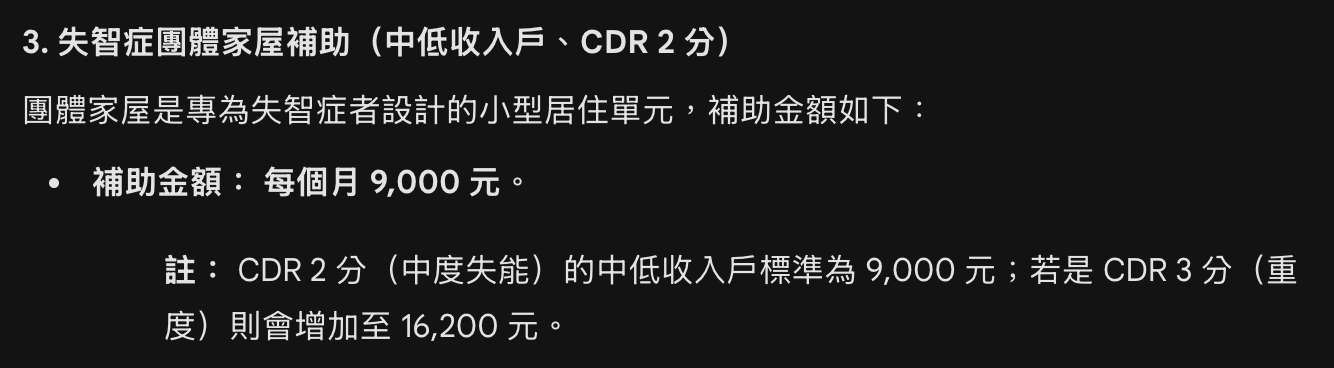

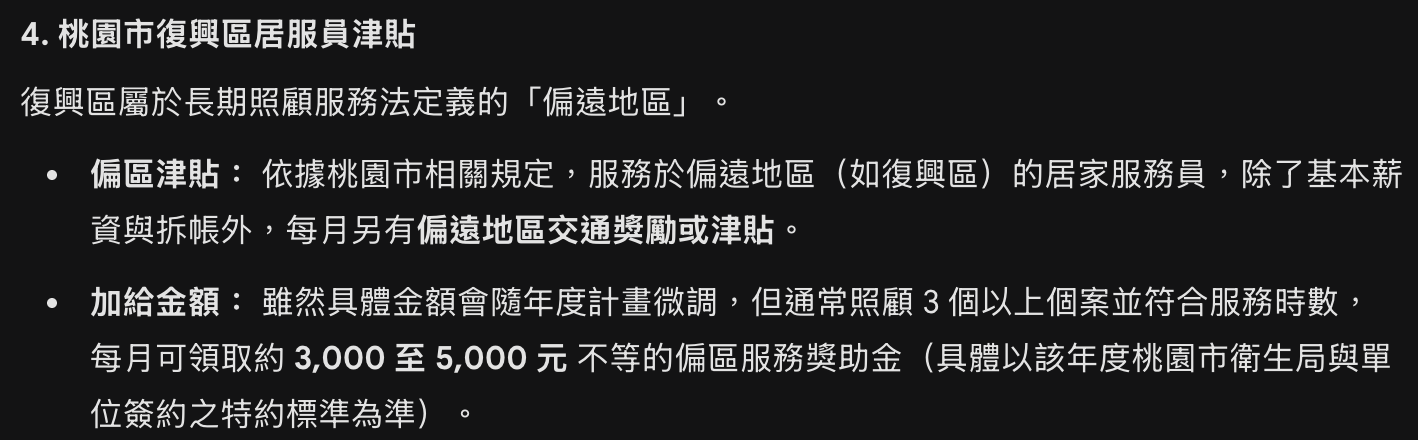

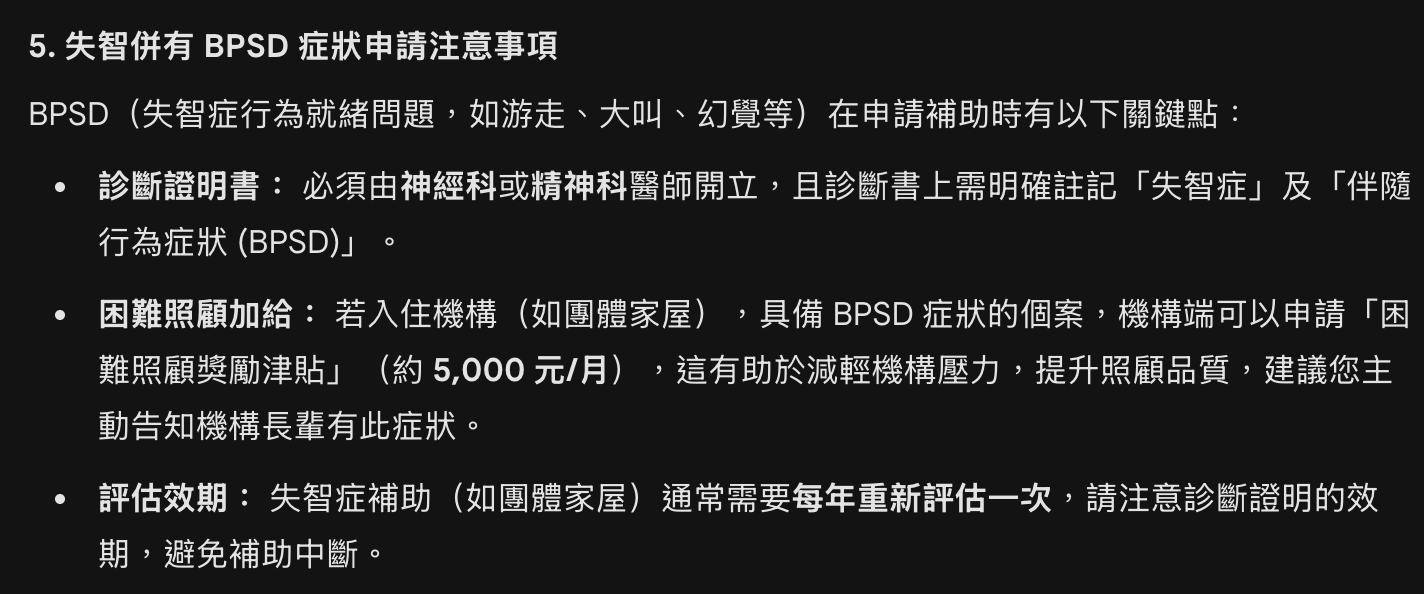

### 此 Project

1. 「營養餐飲服務」每餐補助多少錢？一個人一天最多幾餐？

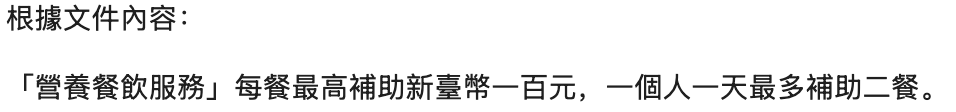

2. 我想申請「身心障礙者日間照顧機構費用」，最晚什麼時候要申請？

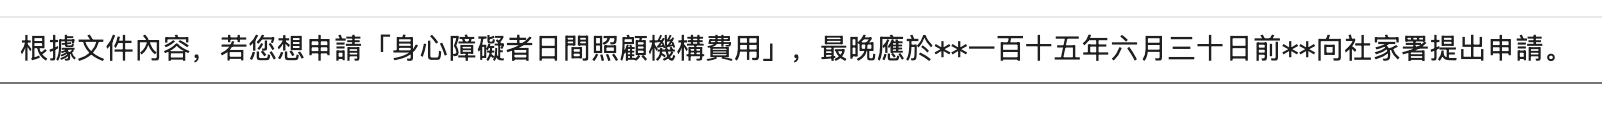

3. 我是中低收入戶，失智等級 CDR 2 分，住進團體家屋一個月補助多少？

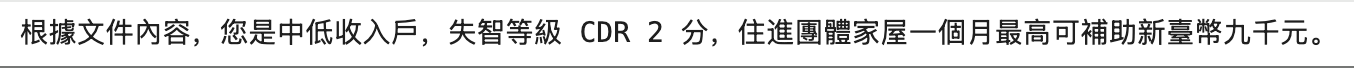

4. 如果我在「桃園市復興區」當居服員，照顧 3 個以上的個案，每月有多少獎勵津貼？

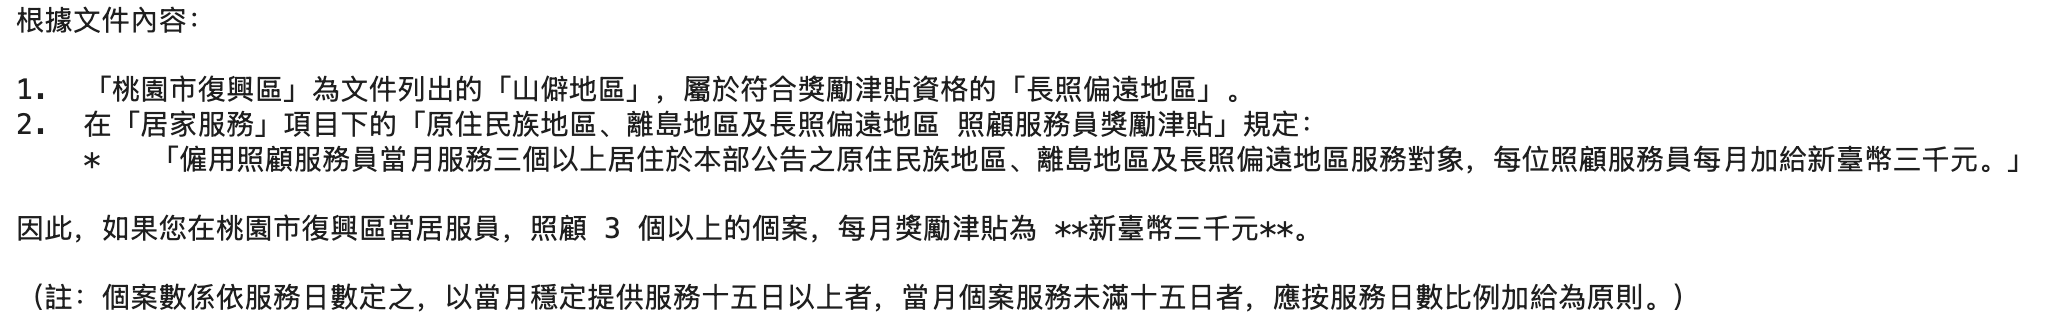

5. 我家長輩失智併有 BPSD 症狀，在申請補助時有什麼要注意的？

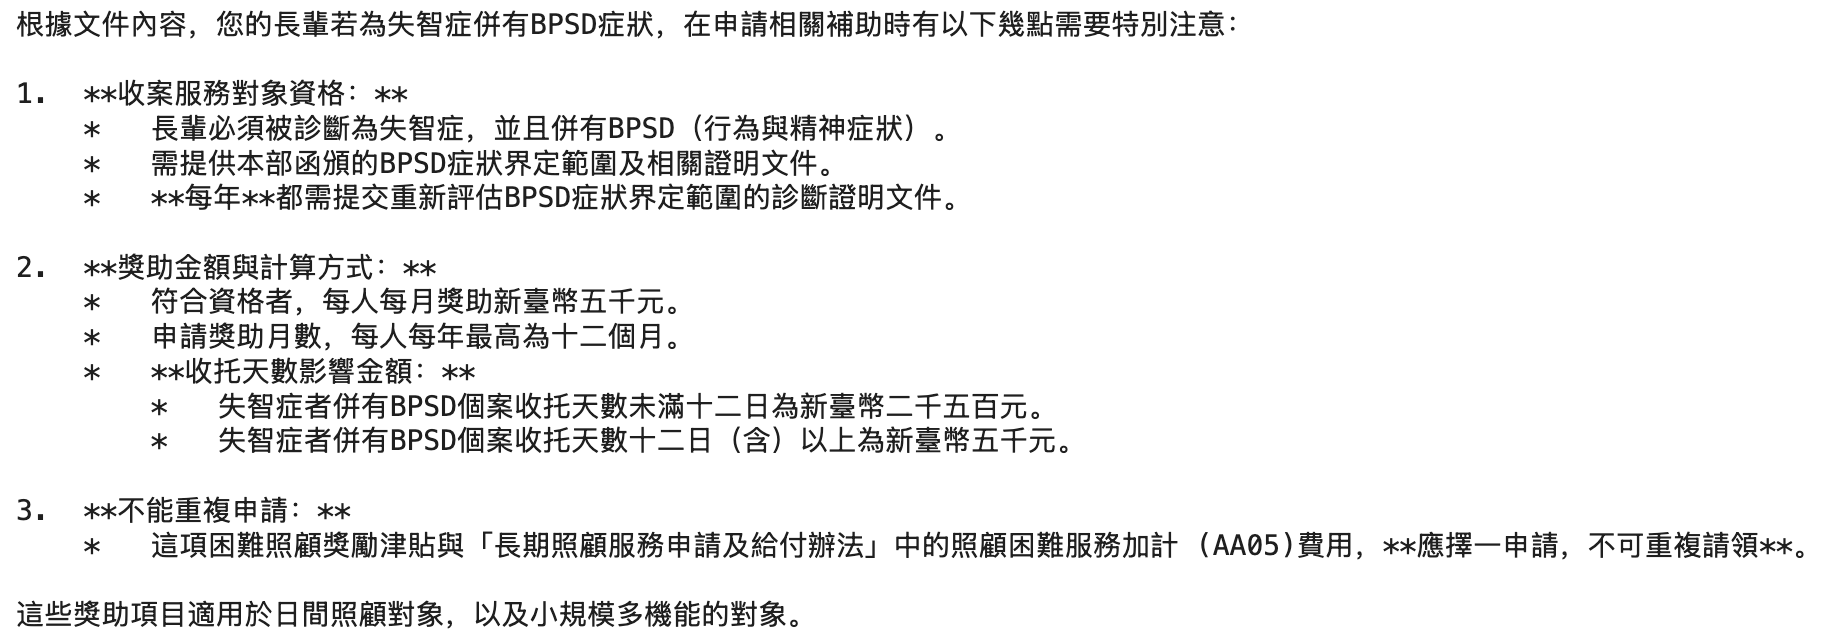

可發現 Gemini 有時只會給個模糊的範圍且提供非必要的資訊，而本 project 則是給出非常肯定的答案
且本 project 每一個問題皆有附上條文出處，Gemini 則無

## Findings and conclusions

1. System Performance:

本研究成功構建了一個基於 RAG 技術的長照機構補助諮詢助手。
實驗結果證明，該系統能有效且精準的依據官方的補助方法文件進行回答，降低了 AI 產生「幻覺」的機率

2. Value Proposition:

減少了機構服務人員查詢複雜條文的時間，能將更多時間用在照顧個案上

3. Future Work:

未來可加入解析「申請表單 PDF」的功能，直接判斷機構填寫的資料是否符合補助規範

建立自動更新機制，當更新最新補助辦法時，向量資料庫能即時同步，確保諮詢結果過時